In [4]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)

# import pandas as pd
# import matplotlib.pyplot as plt
# import reciprocalspaceship as rs
# from occupancy import *
# from plotting3d import *
%load_ext autoreload 
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-08-30 14:31:33,606: systematic_plots: WARNING: Setting sigma to 10 (2407930828.py:81)
2025-08-30 14:31:33,661: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:31:34,081: meteorize: WARNING: Used threshold for posmask: 0.373, found 51 blobs (meteorize.py:581)


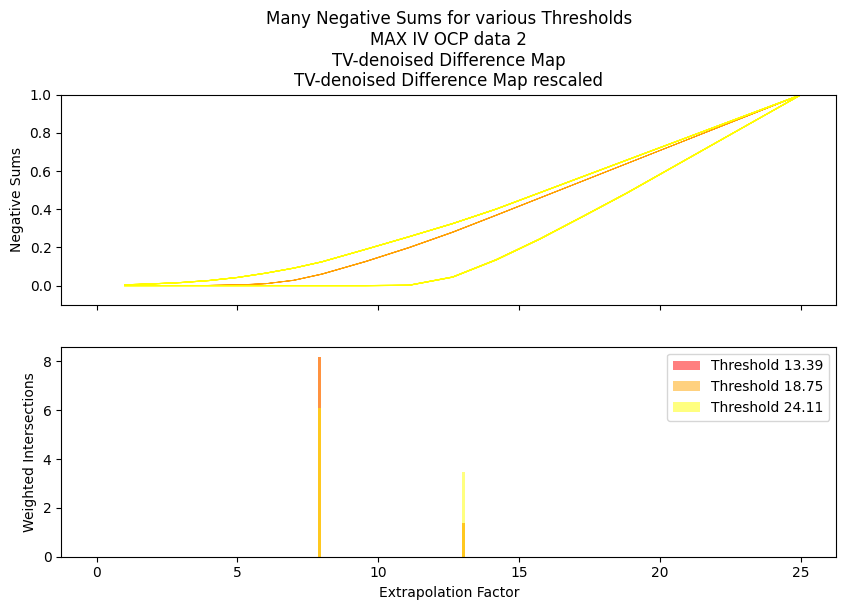

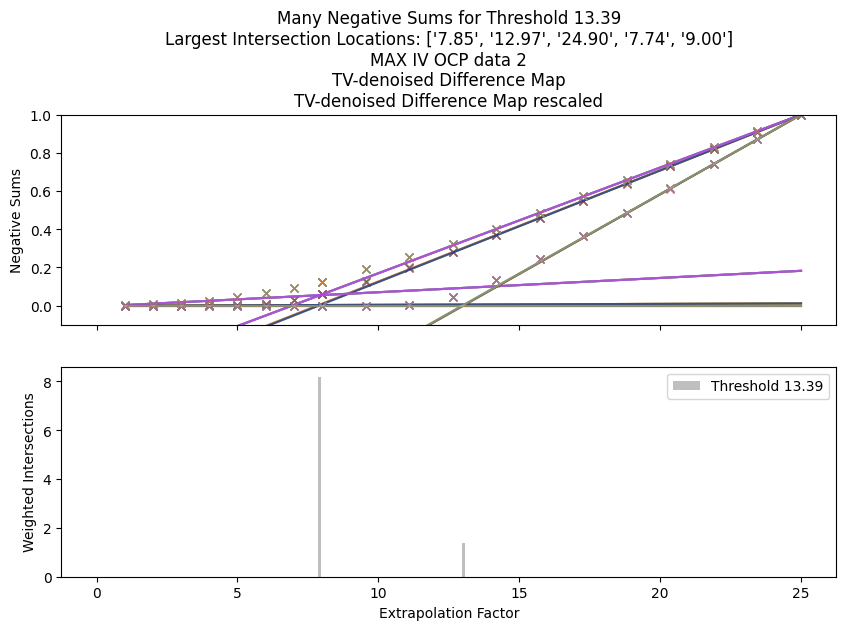

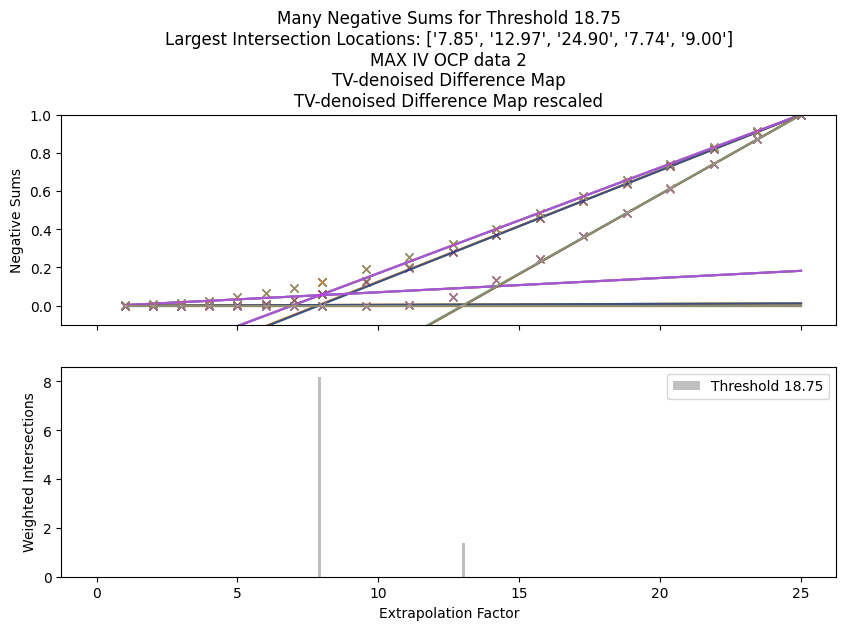

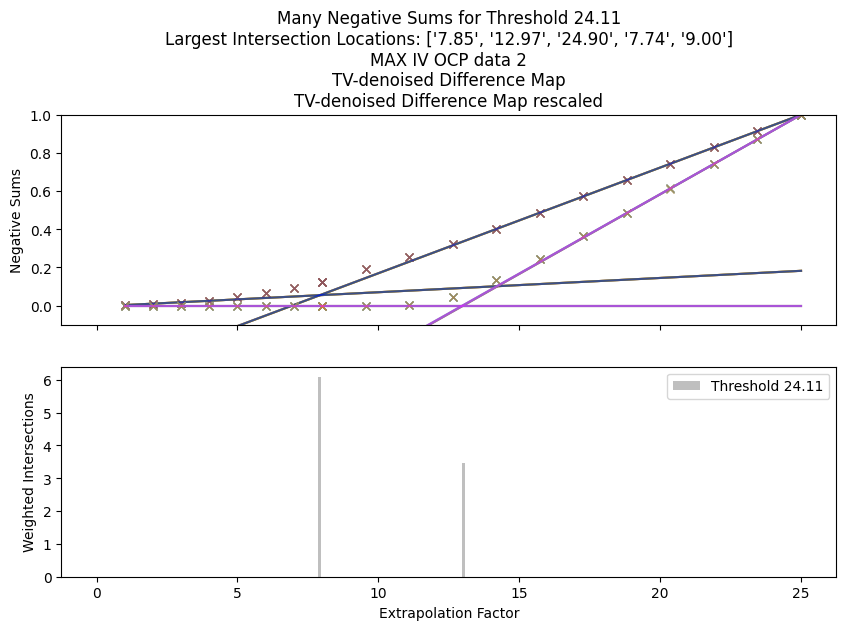

2025-08-30 14:31:39,449: systematic_plots: WARNING: Setting sigma to 8 (2407930828.py:81)
2025-08-30 14:31:39,506: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:31:39,964: meteorize: WARNING: Used threshold for posmask: 0.299, found 86 blobs (meteorize.py:581)


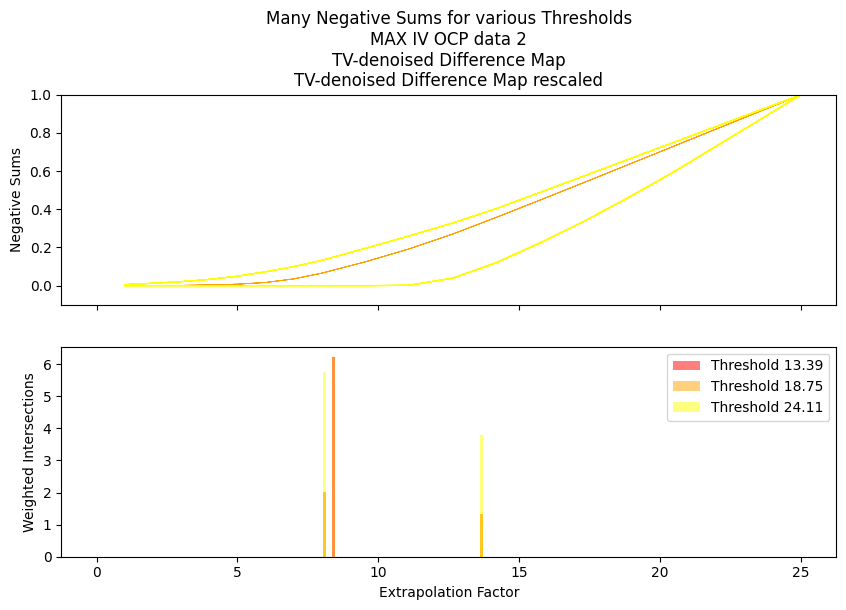

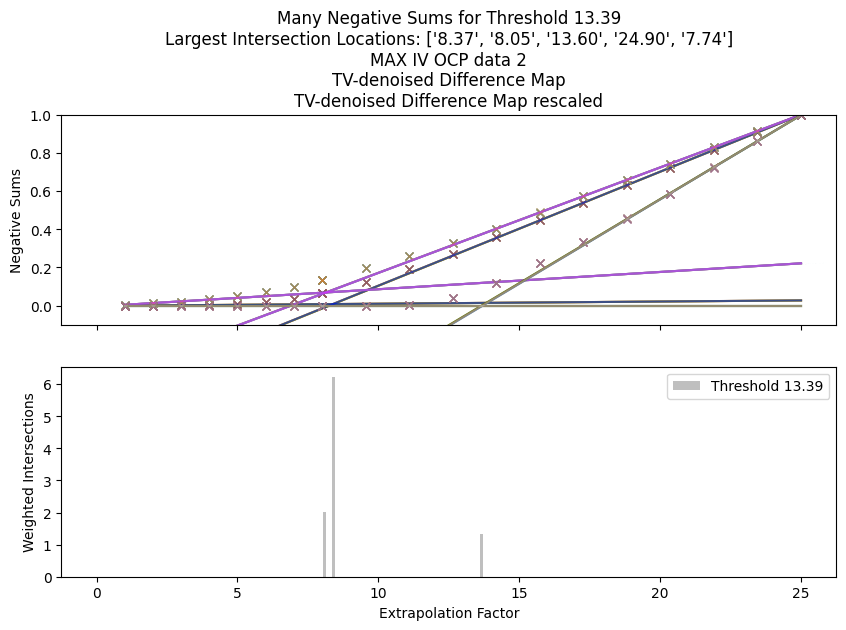

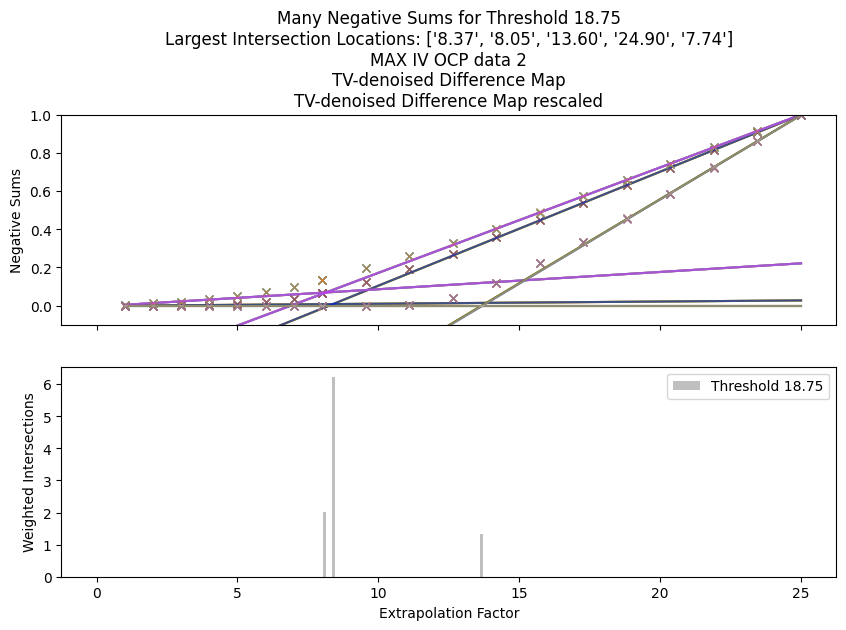

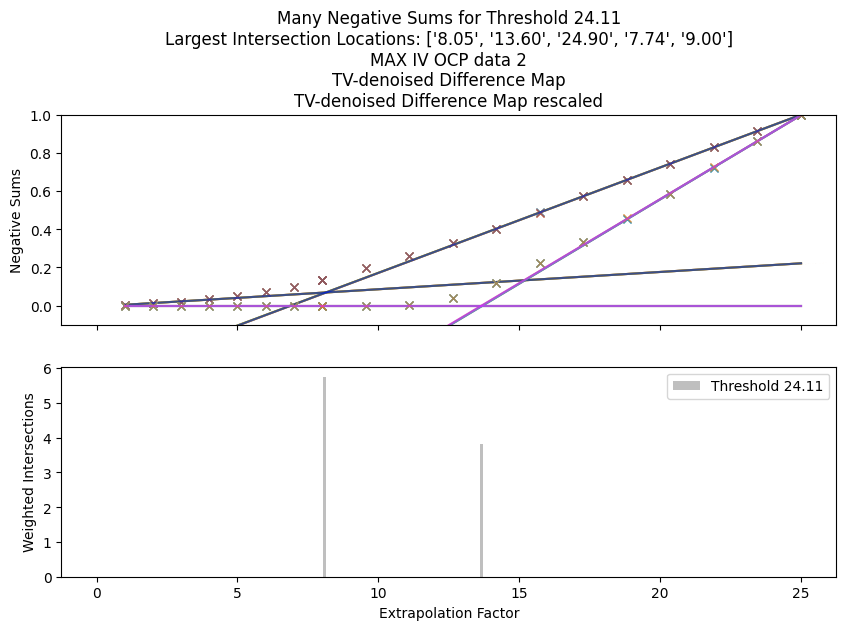

2025-08-30 14:31:45,638: systematic_plots: WARNING: Setting sigma to 3 (2407930828.py:81)
2025-08-30 14:31:45,720: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:31:46,158: meteorize: WARNING: Used threshold for posmask: 0.112, found 973 blobs (meteorize.py:581)


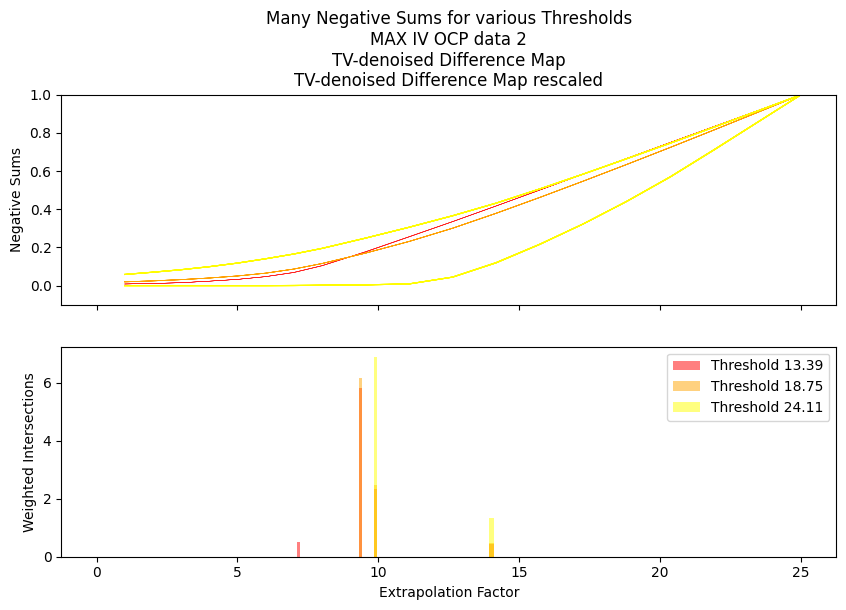

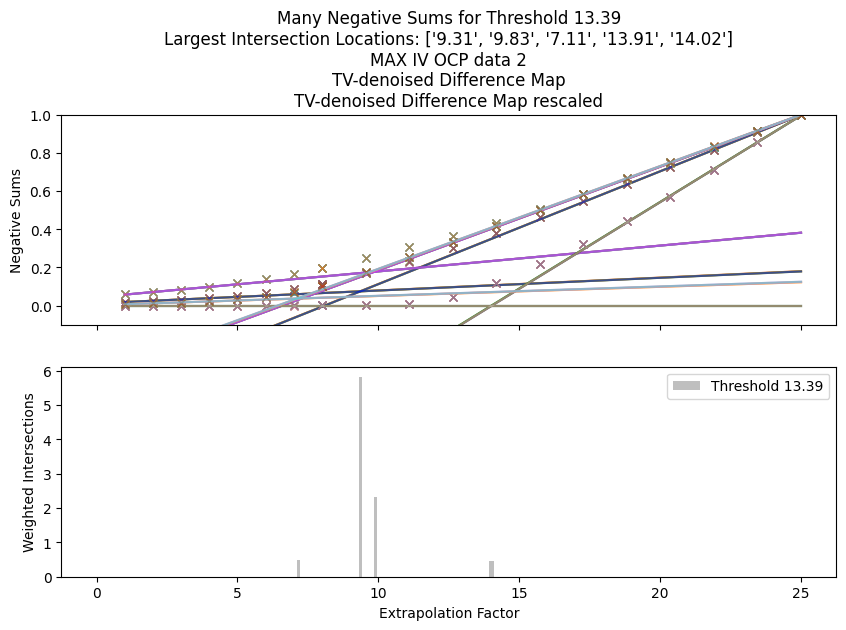

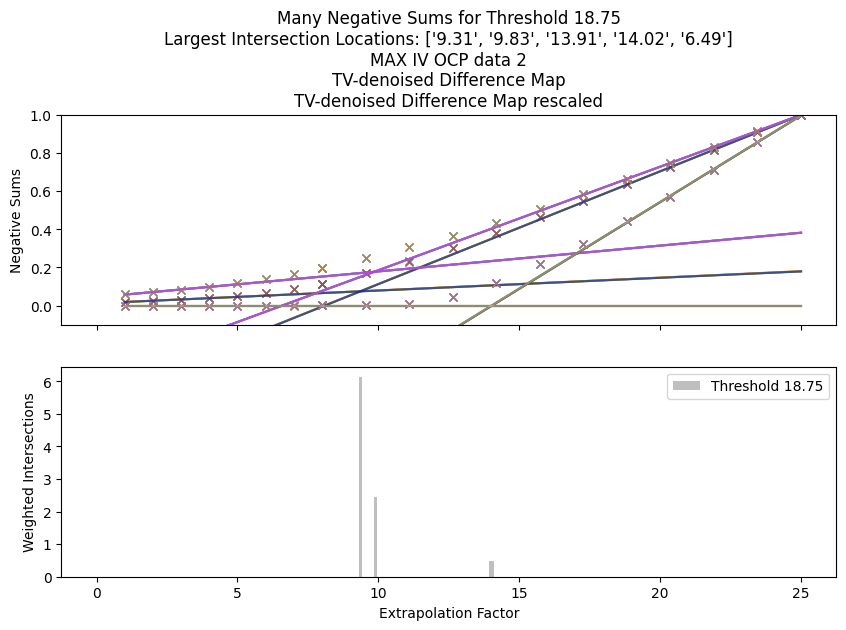

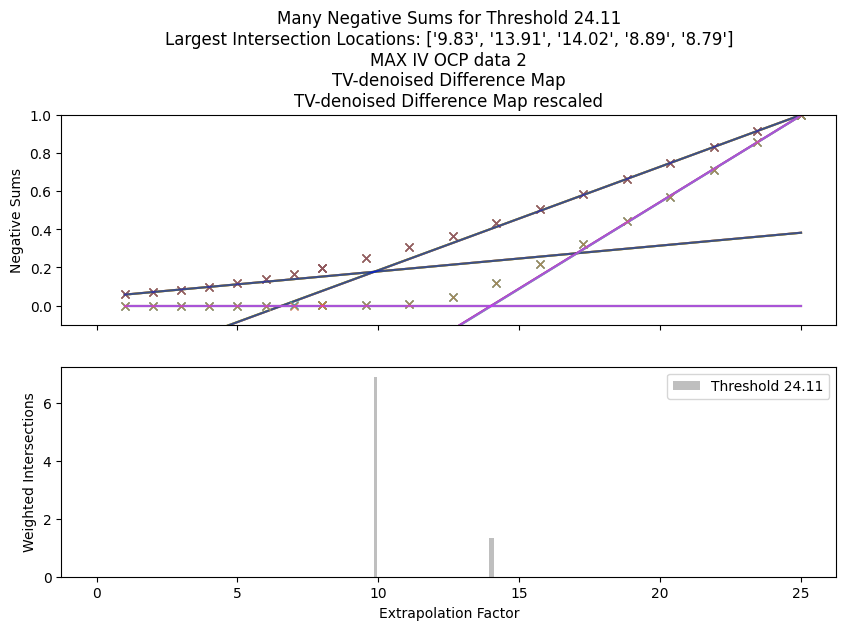

2025-08-30 14:31:55,816: systematic_plots: WARNING: Setting sigma to 4 (2407930828.py:81)
2025-08-30 14:31:55,904: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:31:56,369: meteorize: WARNING: Used threshold for posmask: 0.149, found 457 blobs (meteorize.py:581)


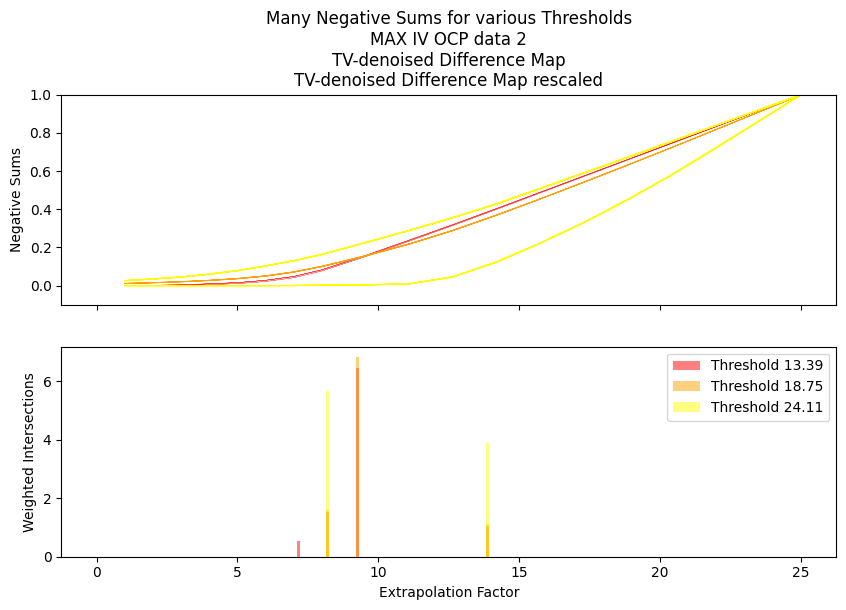

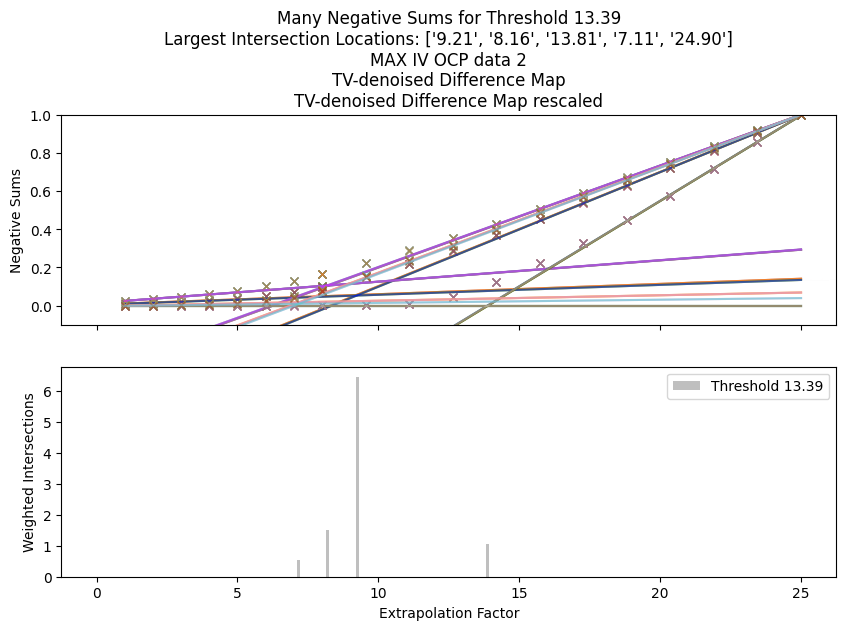

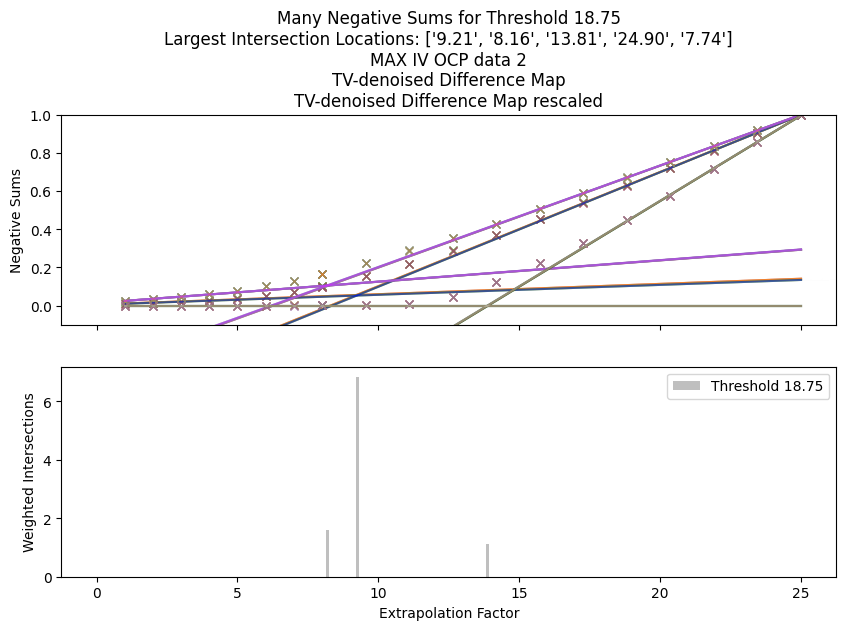

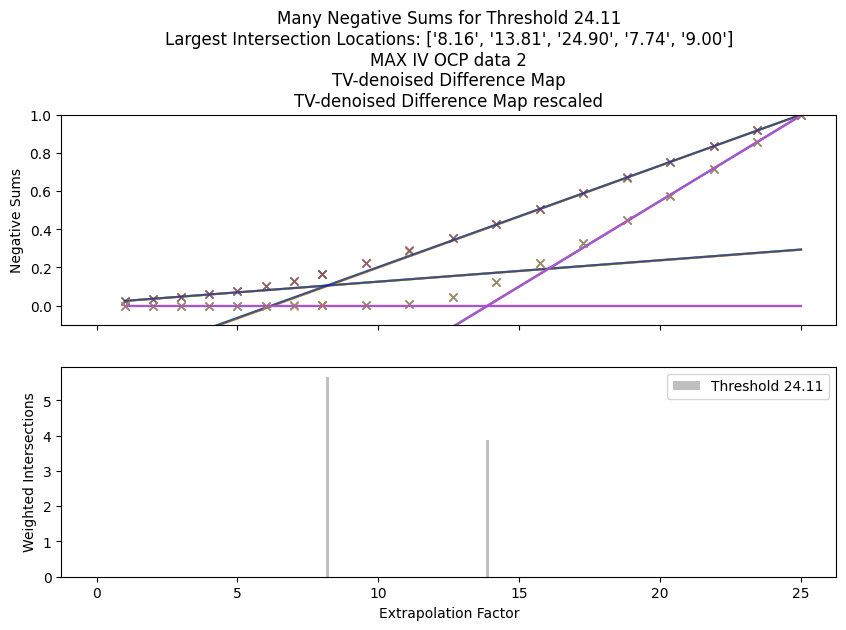

2025-08-30 14:32:03,935: systematic_plots: WARNING: Setting sigma to 5 (2407930828.py:81)
2025-08-30 14:32:03,990: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:32:04,424: meteorize: WARNING: Used threshold for posmask: 0.187, found 289 blobs (meteorize.py:581)


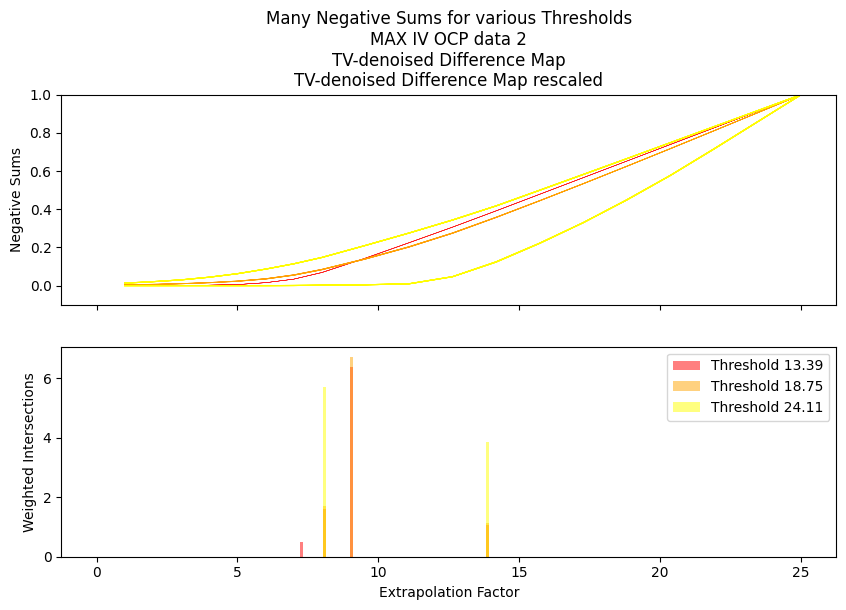

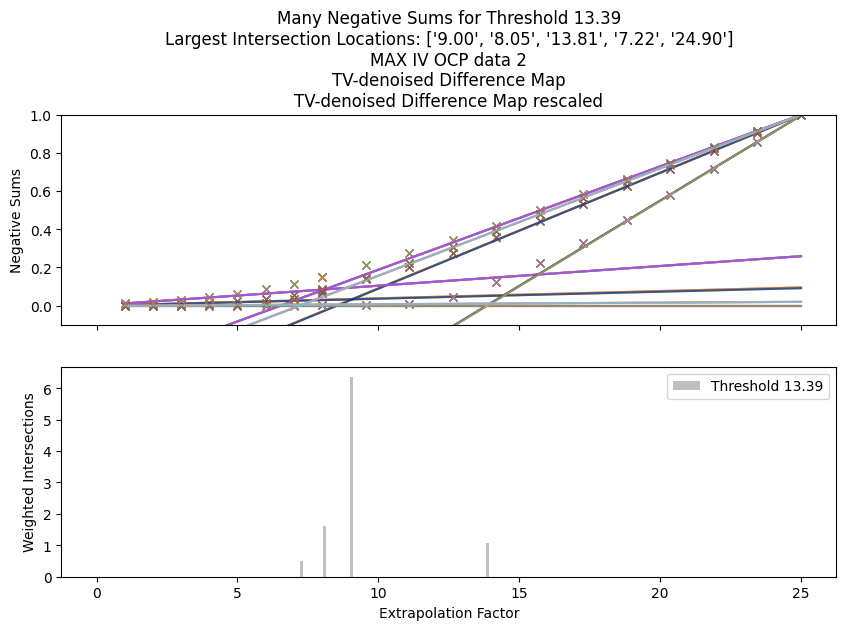

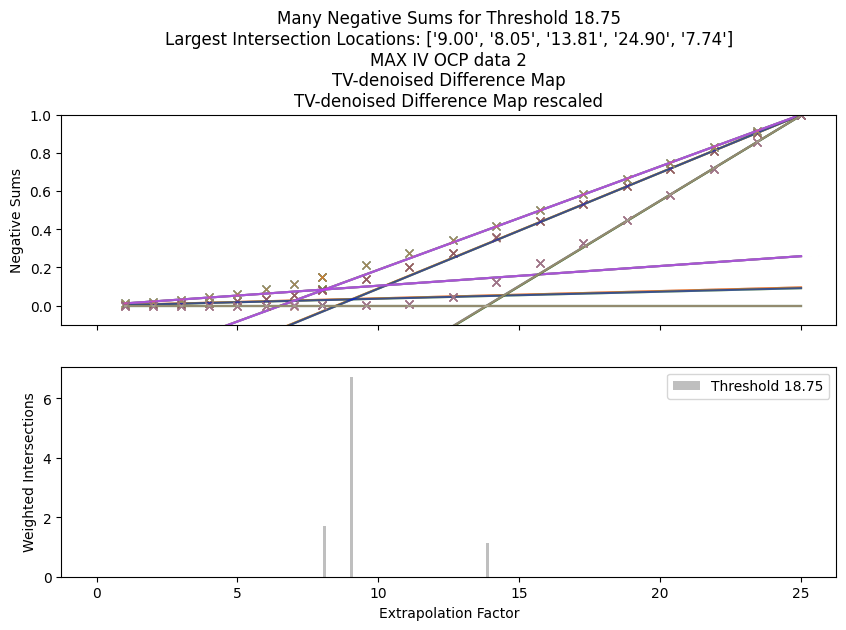

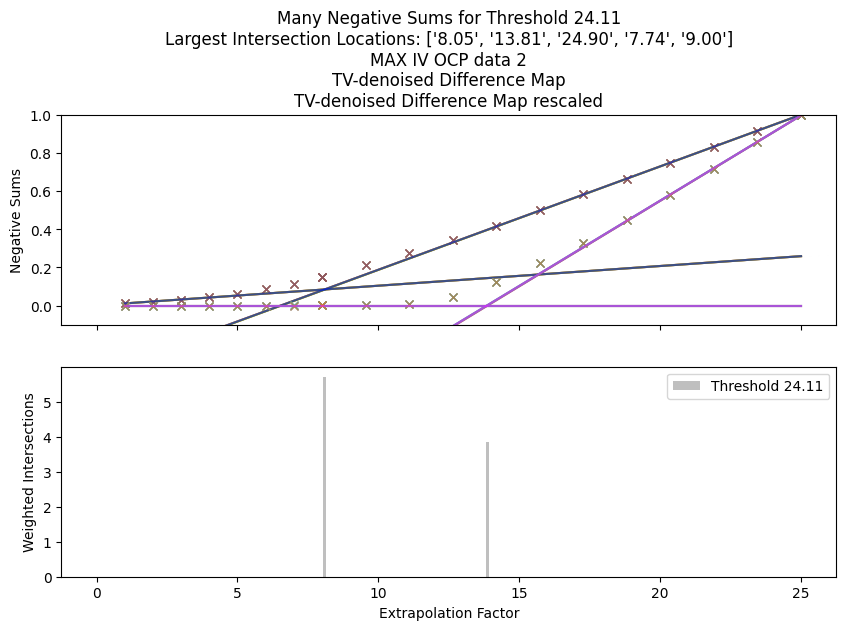

2025-08-30 14:32:11,698: systematic_plots: WARNING: Setting sigma to 6 (2407930828.py:81)
2025-08-30 14:32:11,756: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.15 (systematic_plots.py:2083)
2025-08-30 14:32:12,217: meteorize: WARNING: Used threshold for posmask: 0.224, found 174 blobs (meteorize.py:581)


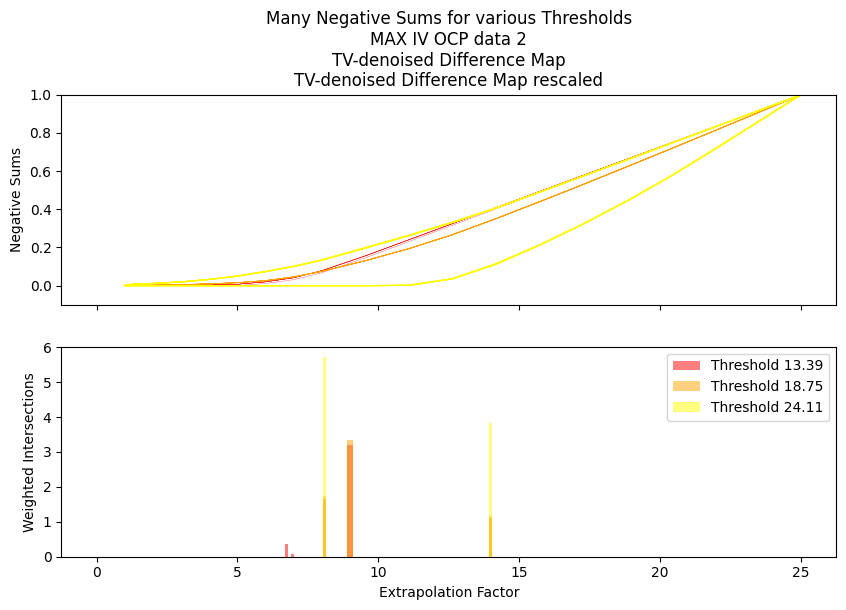

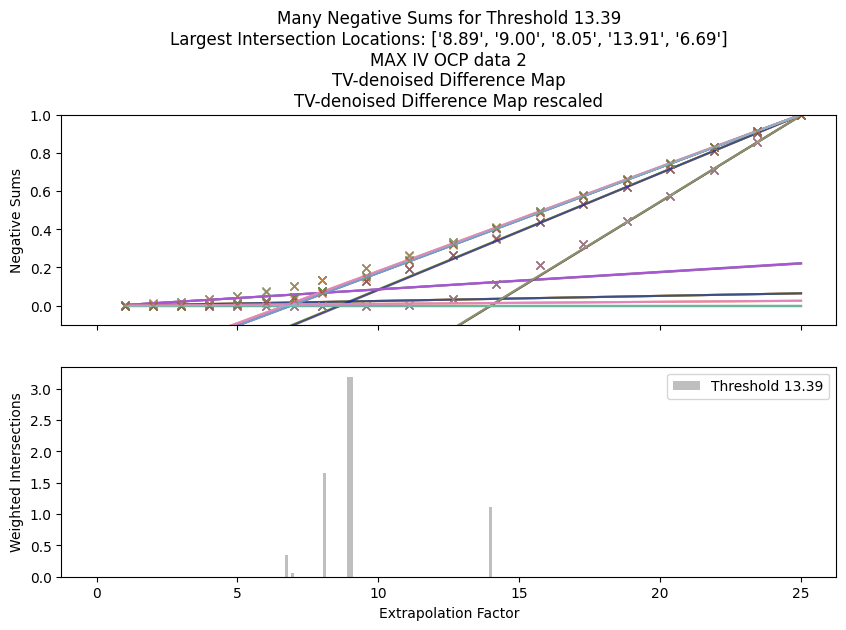

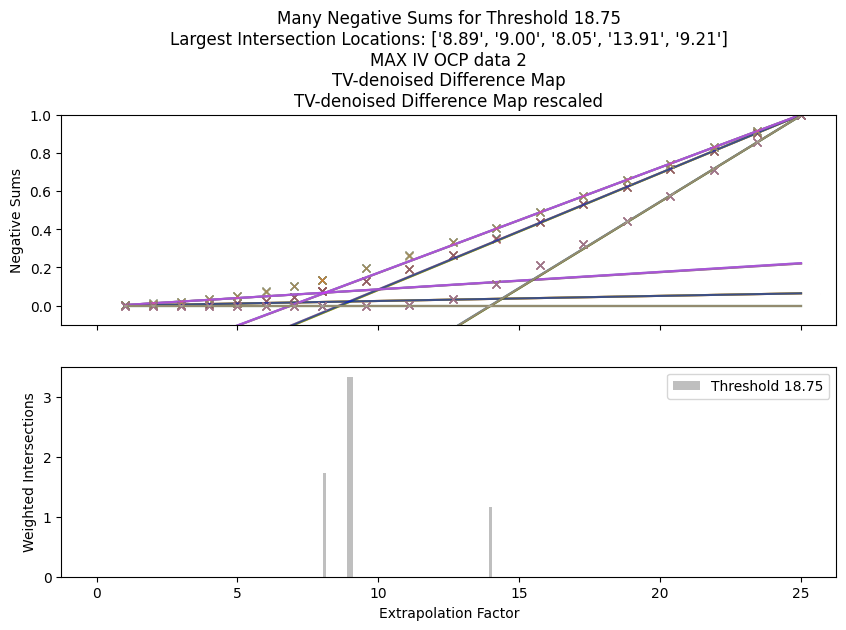

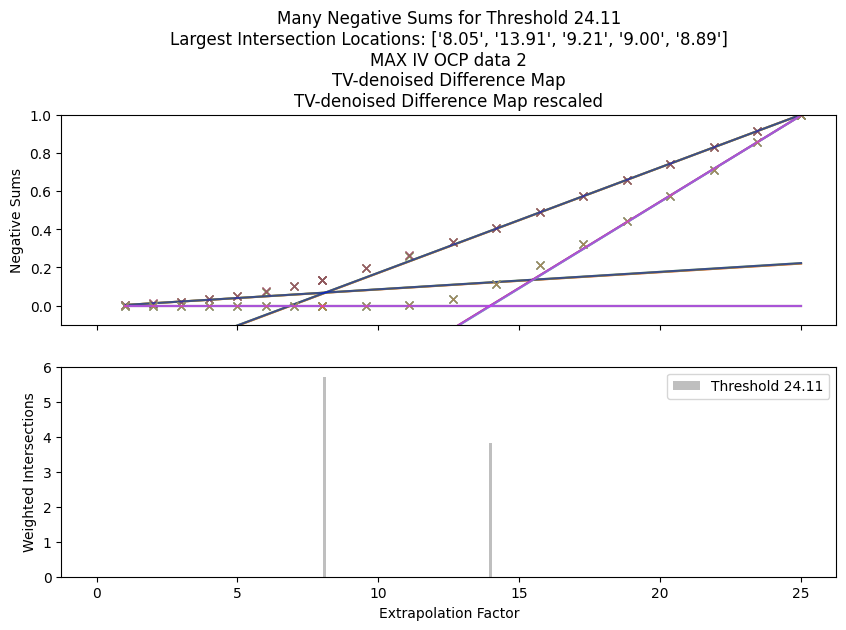

In [6]:

%load_ext autoreload
%autoreload 2

from systematic_plots import *

# pdbloc_light, map_xtrs = load_photolyase_paths()
filename_dict = {
    "save_fig": False,
    "display": True,
    "rerun": True,
    "rerun_old_only": False,
    "rescaling_diffmaps": True,
}
if filename_dict.get("rescaling_diffmaps", False):
    xtr_settings = {
        "mid_xtr_factor": 8,
        "max_xtr_factor": 25,
    }
else:
    xtr_settings = {
        "mid_xtr_factor": 6,
        "max_xtr_factor": 180,
    }
if False:
    extra_info = {
        "minimum_threshold": 4,
        "maximum_threshold": 14,
    } | xtr_settings
extra_info = {
    "minimum_threshold": 0.5,
    "save_extrapolated": True,
} | xtr_settings

diffmap_ids = ["kweighted"]
diffmap_ids = ["kweighted", "tv"]
diffmap_ids = ["tv"]
diffmap_id = "tv"
rescale_key = "vanilla_diffmap"
function_selection = [
    # "single_negsum_overview",
    # "many_negsum_best_guess",
    "many_negsum_many_thresh",
    # "show_comparison",
]
blob_selection_func = find_most_positive_blobs_fixed_basis

info_containers = load_ocp_paths()
evaluation_path = load_homepath() + "../evaluation/"
if not os.path.exists(evaluation_path):
    os.makedirs(evaluation_path)
outputs = []
# set logger level to warning
logger.setLevel(logging.WARNING)
for info_container in info_containers:
    # logger.info(f"\n\nrunning {info_container['tname']}\n\n")

    diffmaps, map_dark, info_container, evaluation_path_basis = calculate_objects(
        info_container, evaluation_path
    )
    info_container = info_container | extra_info

    # reduce diffmaps to kweigthed and tv:
    # diffmaps = {diffmap_id: diffmaps[diffmap_id] for diffmap_id in diffmap_ids}
    import logging
    logging.getLogger().setLevel(logging.WARNING)
    if filename_dict.get("rescaling_diffmaps", False):

        diffmaps = rescaling_diffmaps(diffmaps, rescale_key)

    diffmap = diffmaps[diffmap_id]
    logger.info(f"\nrunning {info_container['tname']}: {diffmap_id}\n")
    diffmap_path = evaluation_path_basis + f"{diffmap_id}/"
    filestart = f"{info_container['fshort']}_{diffmap_id}_"
    os.makedirs(diffmap_path, exist_ok=True)
    logger.info(f"diffmap_path: {diffmap_path}")
    sigmas = [2, 3, 4, 5, 6, 7, 8, 12, 15]
    sigmas = [2.5, 3, 3.5, 4, 4.5, 5, 5.5,6]
    sigmas = [10, 8, 3,  4, 5, 6 ]
    for sigma in sigmas:
        info_container["sigma"] = sigma
        logger.warning(f"Setting sigma to {sigma}")
        filename_dict2 = {
            "diffmap_path": diffmap_path,
            "filestart": filestart + f"s{sigma}_",
        } | filename_dict
        output = run_plots(
            diffmap,
            map_dark,
            info_container,
            diffmap_id,
            filename_dict2,
            function_selection=function_selection,
            blob_selection_func=blob_selection_func,
        )
        outputs.append((info_container, output))

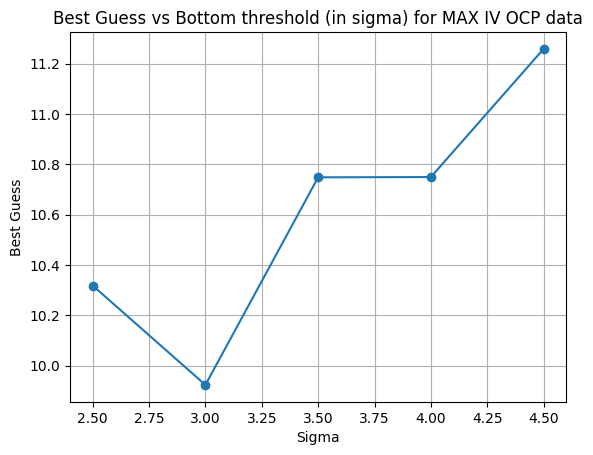

In [44]:
last_guess = [out[1]["many_negsum_best_guess"]["best_guess"][-1] for out in outputs]
plt.figure()
plt.plot(sigmas[:-2], last_guess, marker='o')
plt.xlabel("Sigma")
plt.ylabel("Best Guess")
plt.title(f"Best Guess vs Bottom threshold (in sigma) for {info_container['tname']}")
plt.grid()
# plt.savefig(f"{diffmap_path}{filestart}_best_guess_vs_sigma.png")
plt.show()


In [ ]:

# avg = np.nanmean(diffmaps["tv"]["SIGF"])
# mask = pd.isna(diffmaps["tv"]["SIGF"])
# diffmaps["tv"].loc[mask,"SIGF"] = avg
# diffmaps["tv"].head(20)

NameError: name 'diffmaps2' is not defined

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-08-27 08:59:08,977: systematic_plots: WARNING: Setting sigma to 2.5 (1669074560.py:81)
2025-08-27 08:59:09,034: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.18 (systematic_plots.py:1915)
2025-08-27 08:59:09,318: meteorize: WARNING: Used threshold for posmask: 0.075, found 1220 blobs (meteorize.py:580)


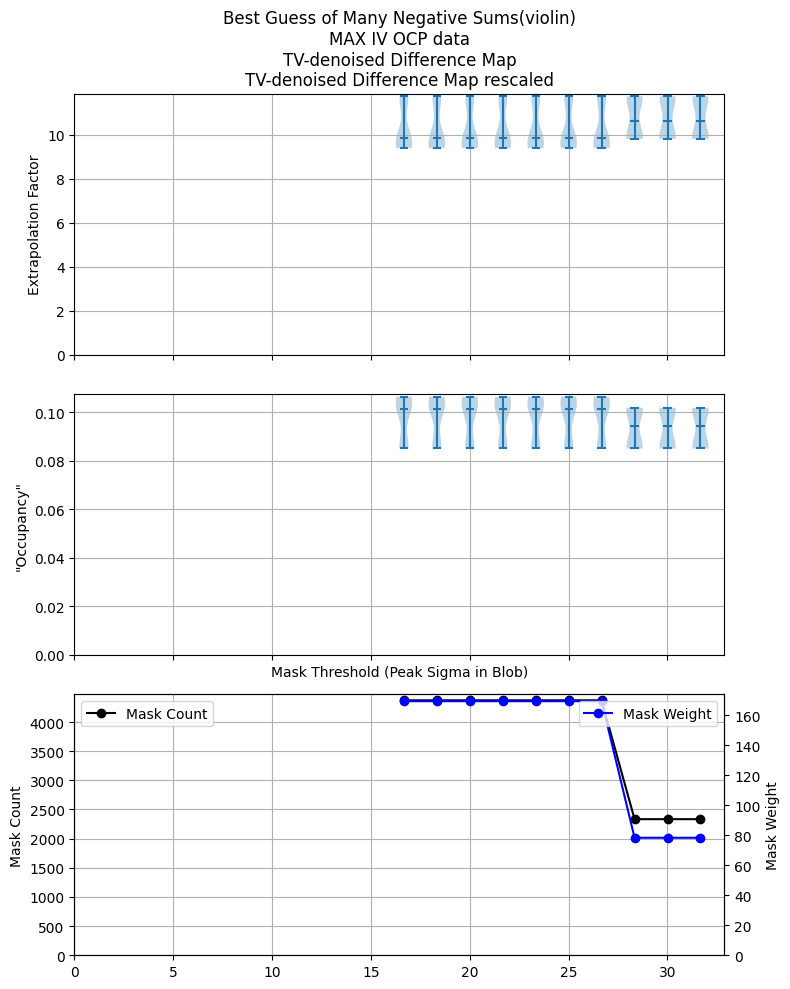

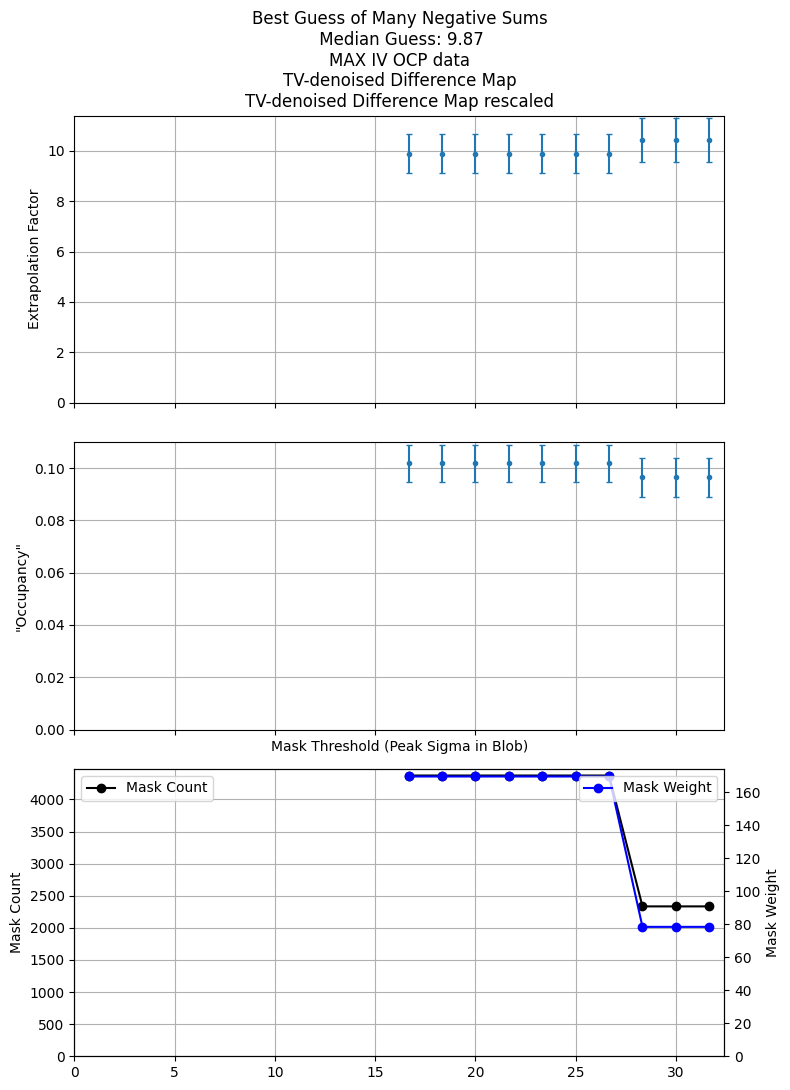

2025-08-27 08:59:32,107: meteorize: WARNING: Used threshold for posmask: 0.075, found 1220 blobs (meteorize.py:580)
2025-08-27 08:59:38,765: systematic_plots: WARNING: np.sum(intersection_hist>0)=5) (systematic_plots.py:742)
2025-08-27 08:59:38,766: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                    

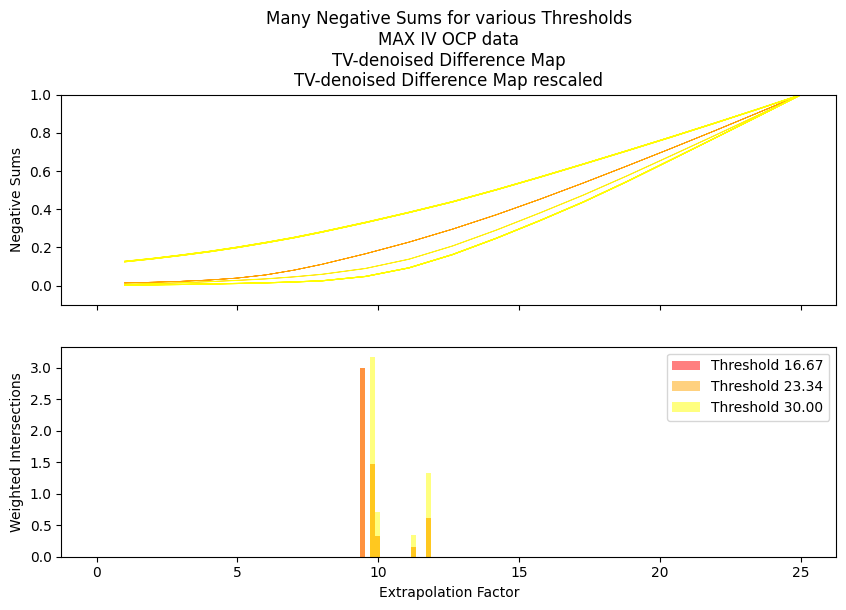

2025-08-27 08:59:39,010: systematic_plots: WARNING: np.sum(intersection_hist>0)=5) (systematic_plots.py:742)
2025-08-27 08:59:39,011: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         2.98824004 0.
                                  1.46680316

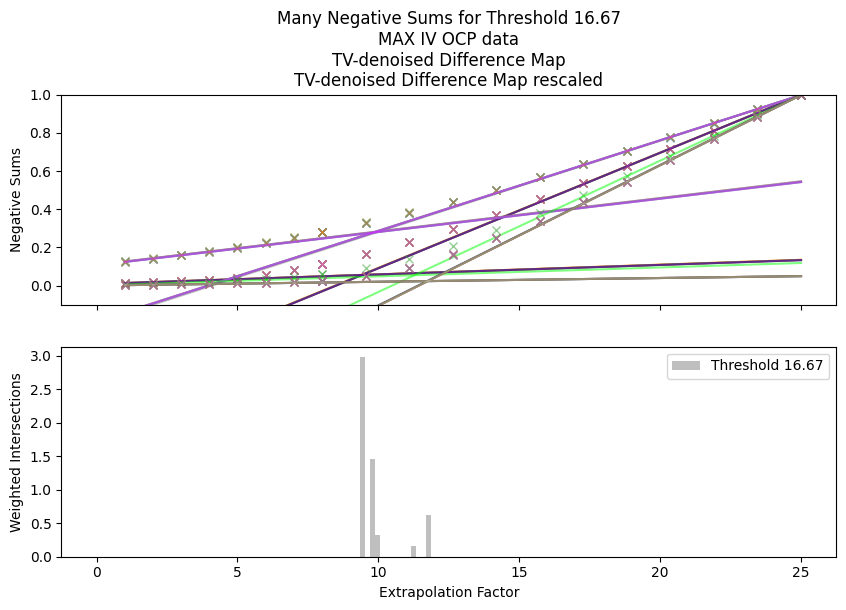

2025-08-27 08:59:39,140: systematic_plots: WARNING: np.sum(intersection_hist>0)=5) (systematic_plots.py:742)
2025-08-27 08:59:39,140: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         2.98824004 0.
                                  1.46680316

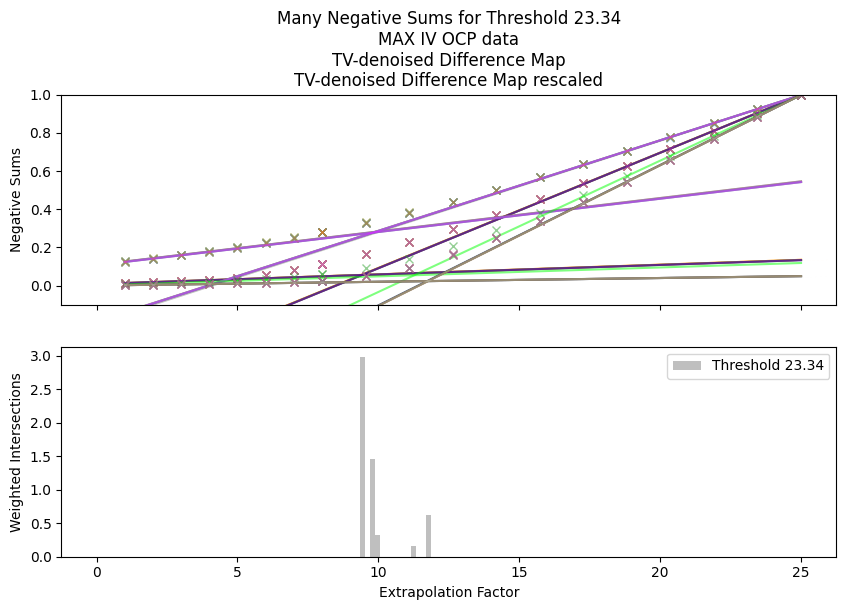

2025-08-27 08:59:39,270: systematic_plots: WARNING: np.sum(intersection_hist>0)=4) (systematic_plots.py:742)
2025-08-27 08:59:39,271: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  3.17114571

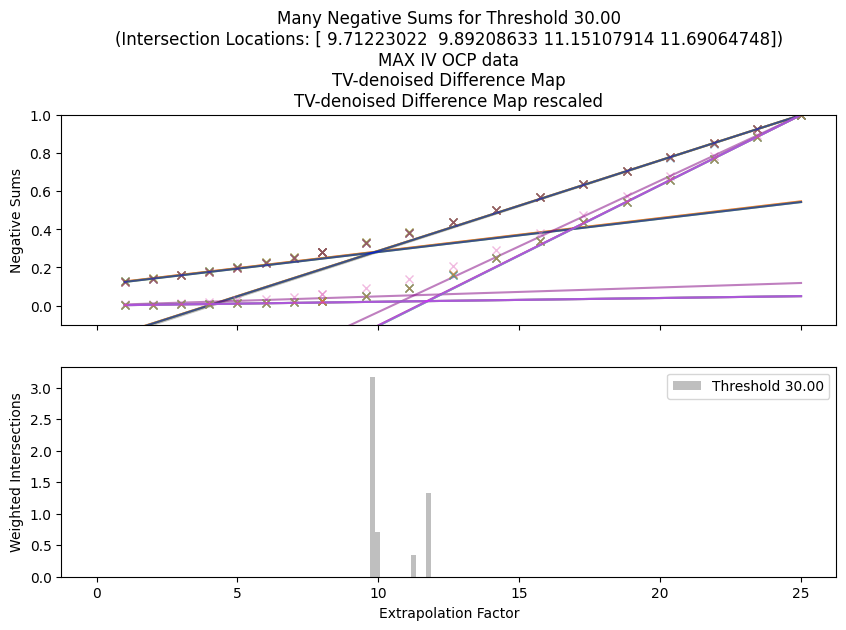

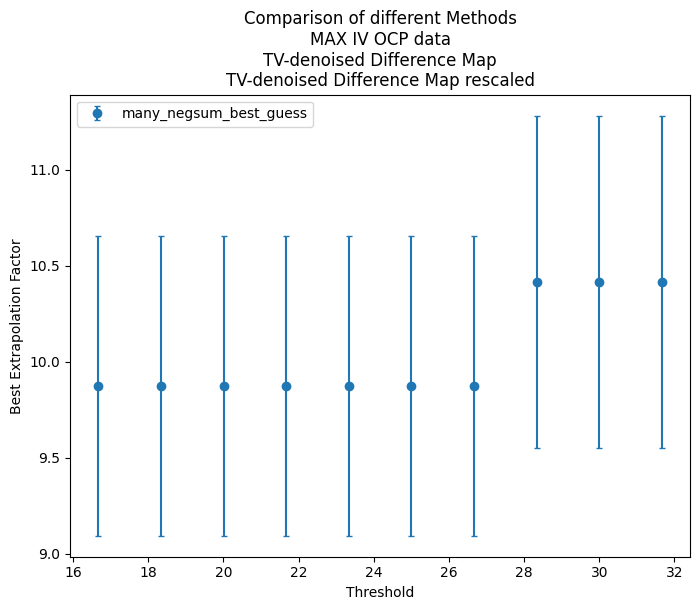

2025-08-27 08:59:39,401: systematic_plots: WARNING: Setting sigma to 4.5 (1669074560.py:81)
2025-08-27 08:59:39,439: systematic_plots: ERROR: Diffmap 3*sig: 0.02, max negative: -0.18 (systematic_plots.py:1915)
2025-08-27 08:59:39,752: meteorize: WARNING: Used threshold for posmask: 0.135, found 364 blobs (meteorize.py:580)


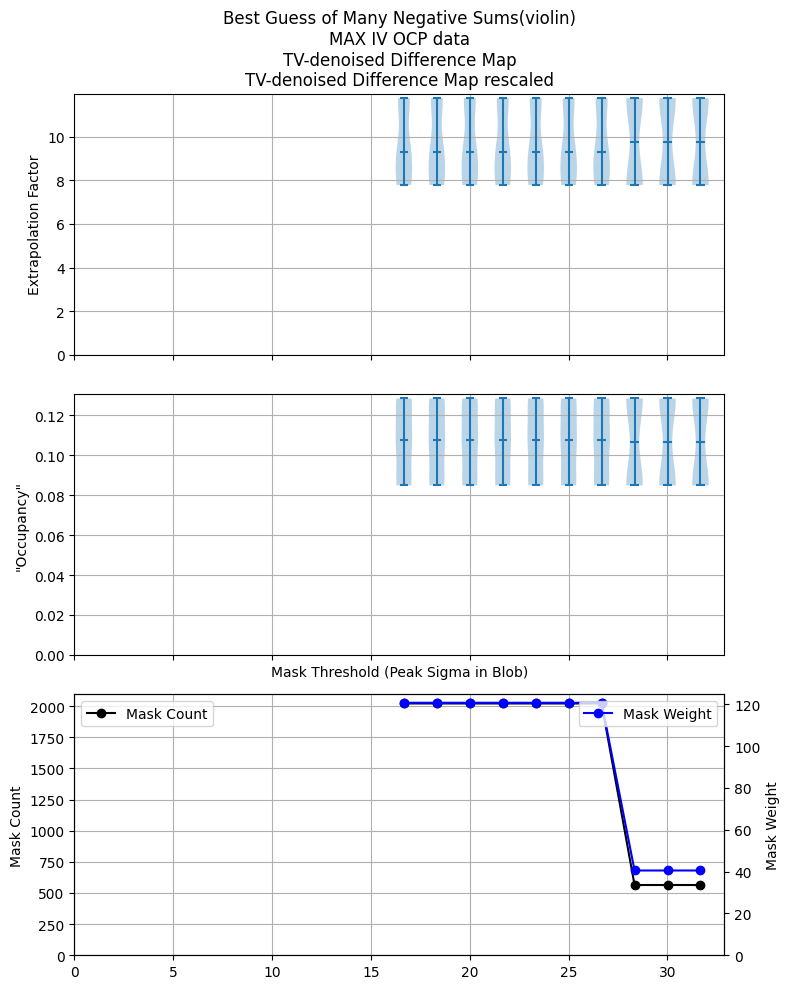

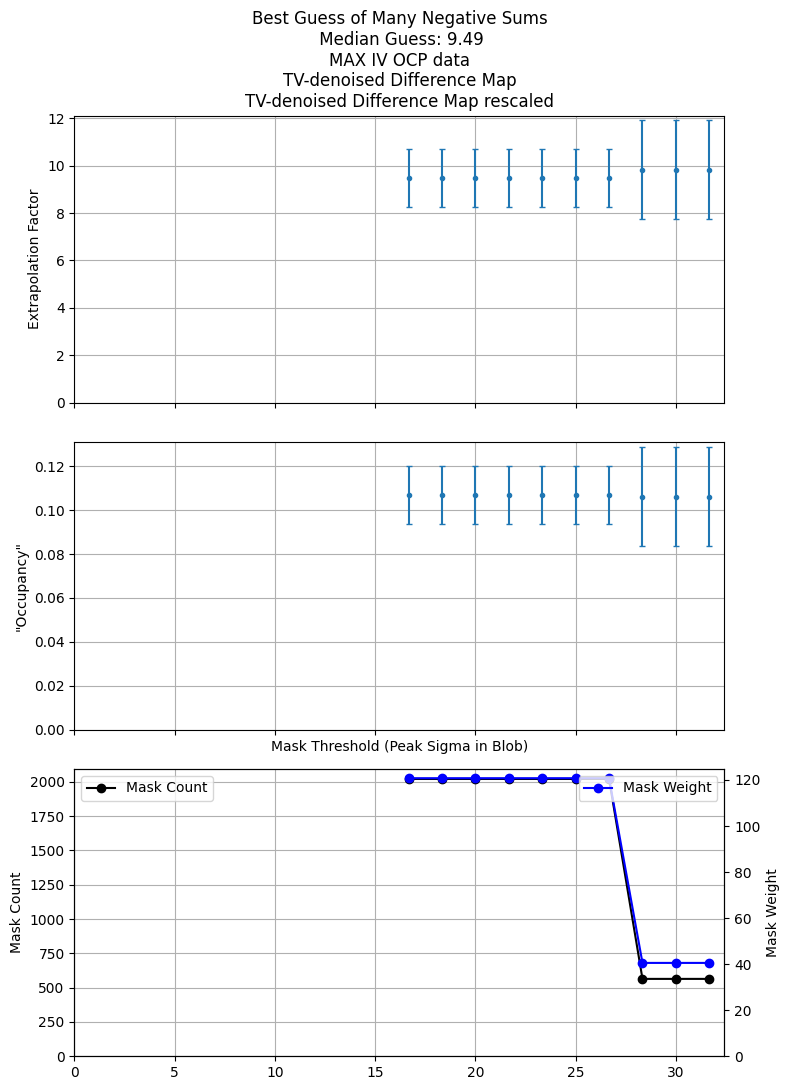

2025-08-27 08:59:53,809: meteorize: WARNING: Used threshold for posmask: 0.135, found 364 blobs (meteorize.py:580)
2025-08-27 08:59:57,878: systematic_plots: WARNING: np.sum(intersection_hist>0)=3) (systematic_plots.py:742)
2025-08-27 08:59:57,878: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.91046551 0.         0.         0.         0.
                     

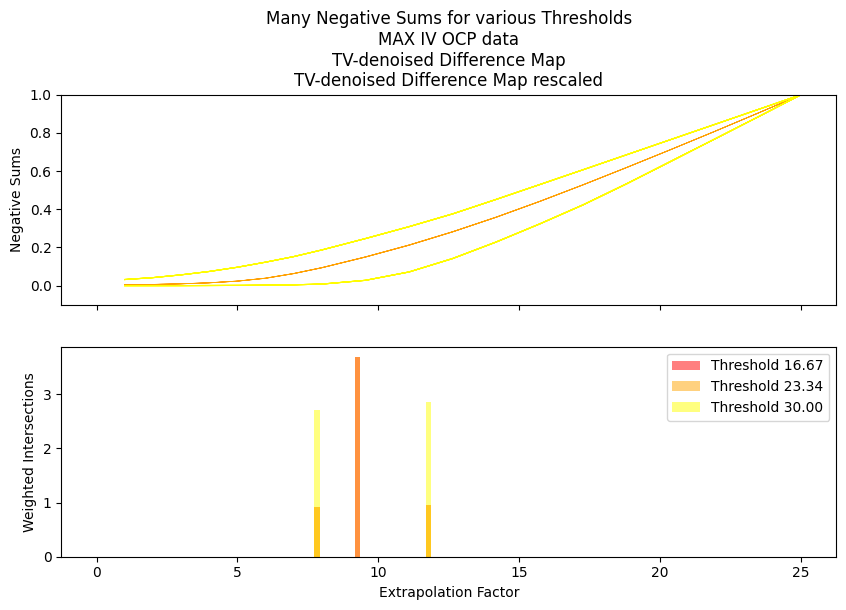

2025-08-27 08:59:58,120: systematic_plots: WARNING: np.sum(intersection_hist>0)=3) (systematic_plots.py:742)
2025-08-27 08:59:58,120: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.91046551 0.         0.         0.         0.
                                  0.         0.         0.         3.69312594 0.         0.
                                  0.        

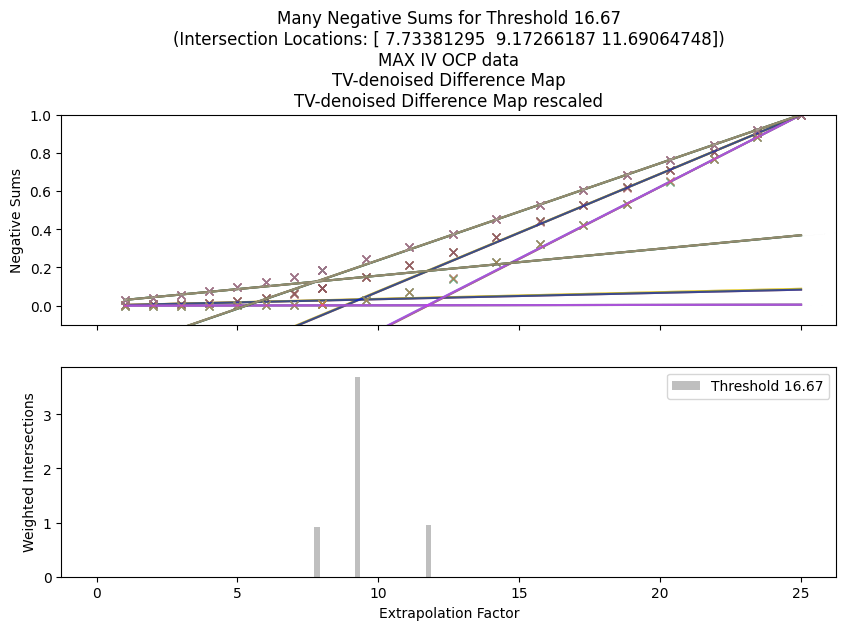

2025-08-27 08:59:58,360: systematic_plots: WARNING: np.sum(intersection_hist>0)=3) (systematic_plots.py:742)
2025-08-27 08:59:58,360: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.91046551 0.         0.         0.         0.
                                  0.         0.         0.         3.69312594 0.         0.
                                  0.        

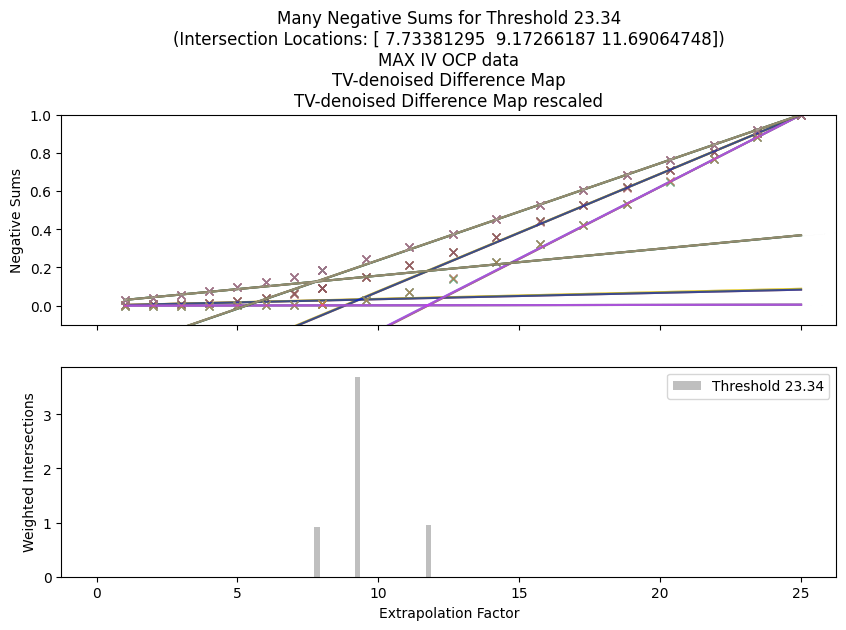

2025-08-27 08:59:58,487: systematic_plots: WARNING: np.sum(intersection_hist>0)=2) (systematic_plots.py:742)
2025-08-27 08:59:58,487: systematic_plots: WARNING: [0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.         2.71158528 0.         0.         0.         0.
                                  0.         0.         0.         0.         0.         0.
                                  0.        

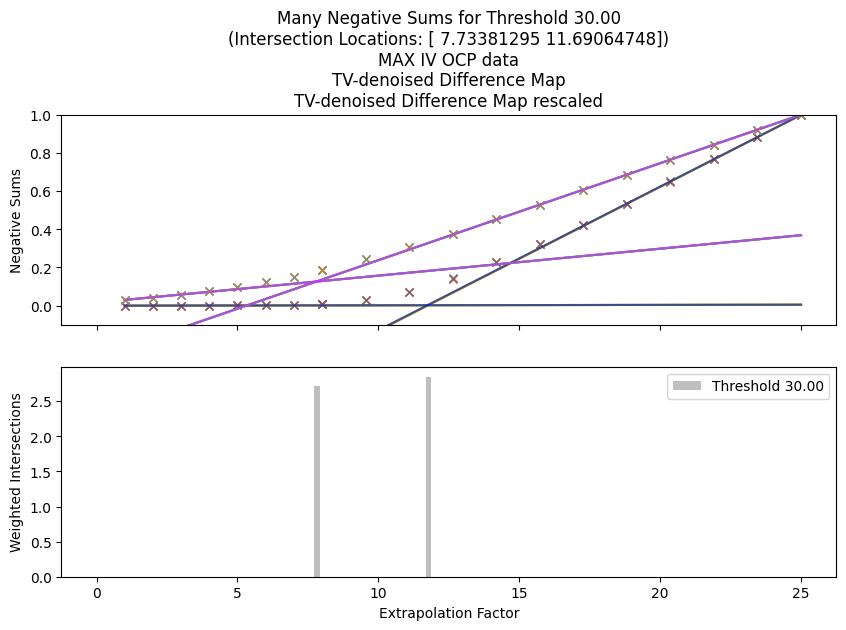

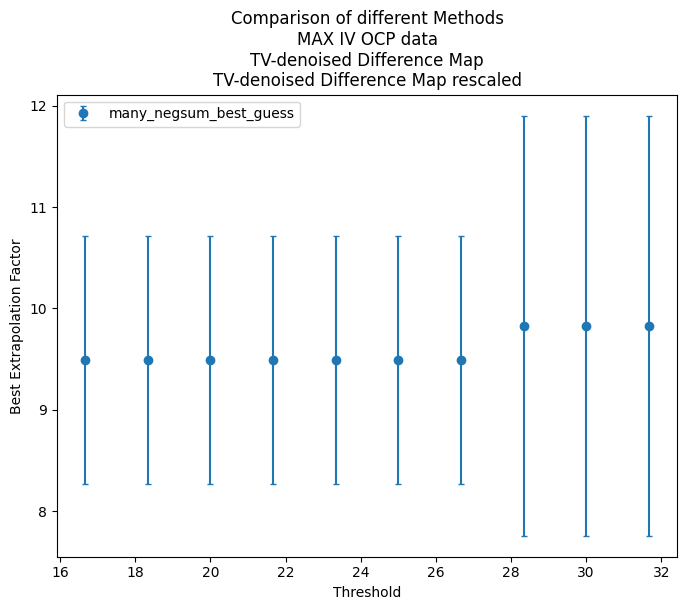

In [5]:

%load_ext autoreload
%autoreload 2

from systematic_plots import *

# pdbloc_light, map_xtrs = load_photolyase_paths()
filename_dict = {
    "save_fig": False,
    "display": True,
    "rerun": True,
    "rerun_old_only": False,
    "rescaling_diffmaps": True,
}
if filename_dict.get("rescaling_diffmaps", False):
    xtr_settings = {
        "mid_xtr_factor": 8,
        "max_xtr_factor": 25,
    }
else:
    xtr_settings = {
        "mid_xtr_factor": 6,
        "max_xtr_factor": 180,
    }
if False:
    extra_info = {
        "minimum_threshold": 4,
        "maximum_threshold": 14,
    } | xtr_settings
extra_info = {
    "minimum_threshold": 0.4,
    "save_extrapolated": True,
} | xtr_settings

diffmap_ids = ["kweighted"]
diffmap_ids = ["kweighted", "tv"]
diffmap_ids = ["tv"]
diffmap_id = "tv"
rescale_key = "vanilla_diffmap"
function_selection = [
    # "single_negsum_overview",
    "many_negsum_best_guess",
    "many_negsum_many_thresh",
    # "show_comparison",
]
blob_selection_func = find_most_positive_blobs_fixed_basis

info_containers = load_maxiv_paths()
evaluation_path = load_homepath() + "../evaluation/"
if not os.path.exists(evaluation_path):
    os.makedirs(evaluation_path)
outputs = []
# set logger level to warning
logger.setLevel(logging.WARNING)
for info_container in info_containers:
    # logger.info(f"\n\nrunning {info_container['tname']}\n\n")

    diffmaps, map_dark, info_container, evaluation_path_basis = calculate_objects(
        info_container, evaluation_path
    )
    info_container = info_container | extra_info

    # reduce diffmaps to kweigthed and tv:
    # diffmaps = {diffmap_id: diffmaps[diffmap_id] for diffmap_id in diffmap_ids}
    import logging
    logging.getLogger().setLevel(logging.WARNING)
    if filename_dict.get("rescaling_diffmaps", False):

        diffmaps = rescaling_diffmaps(diffmaps, rescale_key)

    diffmap = diffmaps[diffmap_id]
    logger.info(f"\nrunning {info_container['tname']}: {diffmap_id}\n")
    diffmap_path = evaluation_path_basis + f"{diffmap_id}/"
    filestart = f"{info_container['fshort']}_{diffmap_id}_"
    os.makedirs(diffmap_path, exist_ok=True)
    logger.info(f"diffmap_path: {diffmap_path}")
    sigmas = [2, 3, 4, 5, 6, 7, 8, 12, 15]
    sigmas = [2.5, 3, 3.5, 4, 4.5, 5, 5.5,6]
    sigmas = [2.5,  4.5, ]
    for sigma in sigmas:
        info_container["sigma"] = sigma
        logger.warning(f"Setting sigma to {sigma}")
        filename_dict2 = {
            "diffmap_path": diffmap_path,
            "filestart": filestart + f"s{sigma}_",
        } | filename_dict
        output = run_plots(
            diffmap,
            map_dark,
            info_container,
            diffmap_id,
            filename_dict2,
            function_selection=function_selection,
            blob_selection_func=blob_selection_func,
        )
        outputs.append((info_container, output))


In [ ]:
from meteorize import adding_maps
# # def adding_maps(map1: rsmap.Map, map2: rsmap.Map, *, factor1=1, factor2=1, add_uncertainty=True):
# #     common_indices = map1.index.intersection(map2.index)
# #     structure_factors1 = map1.loc[common_indices].to_structurefactor()
# #     structure_factors2 = map2.loc[common_indices].to_structurefactor()
# #     added_structure_factors = (
# #         factor1 * structure_factors1 + factor2 * structure_factors2
# #     )

# #     sum_of_map  = rsmap.Map.from_structurefactor(
# #         added_structure_factors,
# #         index=common_indices,
# #         cell=map1.cell,
# #         spacegroup=map1.spacegroup,
# #     )

# #     if  map1.uncertainties is not None and map2.uncertainties is not None:
# #         sigmaF = np.sqrt(
# #           (factor1 * map1.uncertainties[common_indices]) ** 2
# #         + (factor2 * map2.uncertainties[common_indices]) ** 2
# #         )
# #         sum_of_map.set_uncertainties(pd.Series(sigmaF, index=common_indices))
#    # return sum_of_map

adding_maps(diffmaps["kweighted"], map_dark, factor1=3, add_uncertainty=True)

AttributeError: uncertainties not set for Map object

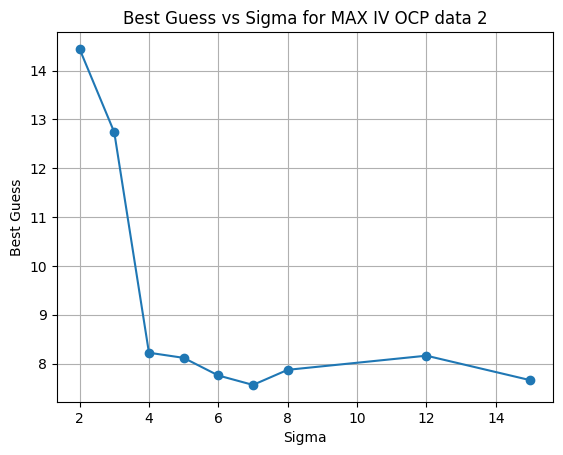

In [ ]:

last_guess = [out[1]["many_negsum_best_guess"]["best_guess"][-1] for out in outputs]
plt.figure()
plt.plot(sigmas, last_guess, marker='o')
plt.xlabel("Sigma")
plt.ylabel("Best Guess")
plt.title(f"Best Guess vs Bottom threshold (in sigma) for {info_container['tname']}")
plt.grid()
# plt.savefig(f"{diffmap_path}{filestart}_best_guess_vs_sigma.png")
plt.show()
